# 🚀 Startup Idea Validator

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/phoebefu6/phoebe-the-builder/blob/main/mini-saas-products/idea-validator/demo.ipynb)
[![Binder](https://mybinder.org/badge_logo.svg)](https://mybinder.org/v2/gh/phoebefu6/phoebe-the-builder/main?labpath=mini-saas-products/idea-validator/demo.ipynb)

> **We build before we validate.** This tool forces the opposite order: score an idea across five dimensions, build a Lean Canvas, and get the *cheapest experiment to test your riskiest assumption* — before you write a line of product code. First build of **Month 6: Mini SaaS Products**.

**This notebook covers:**
1. The five validation dimensions
2. Scoring an idea + turning scores into a verdict
3. Finding the **riskiest assumptions** (validate these first)
4. The cheapest experiment to de-risk each
5. A radar chart of the scorecard


## Step 1 — Five dimensions of a validatable idea

Most ideas die for one of a few reasons. We score each 1-5:

- **Problem Severity** — is this a hair-on-fire problem or a vitamin?
- **Market Size** — enough reachable customers to matter?
- **Differentiation** — is there a 10x axis vs. alternatives (including "do nothing")?
- **Feasibility** — can a small team actually build the core?
- **Willingness to Pay** — will someone hand over money, not just praise?

The trick of Lean Startup isn't the canvas — it's testing your **weakest** assumption first, cheaply.


In [1]:
from __future__ import annotations

from dataclasses import dataclass
from typing import Dict, List

DIMENSIONS = ["Problem Severity", "Market Size", "Differentiation", "Feasibility", "Willingness to Pay"]

EXPERIMENTS = {
    "Problem Severity": "Run 10 problem interviews about the LAST time they hit this pain (don't pitch). Look for emotion + existing workarounds.",
    "Market Size": "Bottom-up TAM = (# reachable customers) x (realistic annual price). Cross-check with search volume.",
    "Differentiation": "1-page comparison vs. the top 3 alternatives incl. 'do nothing'. If you can't name a 10x axis, that's the risk.",
    "Feasibility": "Timebox a 1-day spike on the hardest technical assumption. Ship a manual 'Wizard of Oz' version first.",
    "Willingness to Pay": "Fake-door / pre-sale landing page with a real price + Buy button. Measure clicks-to-checkout; ask 5 people for an LOI.",
}
print("Dimensions:", DIMENSIONS)


Dimensions: ['Problem Severity', 'Market Size', 'Differentiation', 'Feasibility', 'Willingness to Pay']


## Step 2 — Score an idea and get a verdict

Here's a real-sounding idea. We score each dimension (in the app you drag sliders; with a Claude key, a skeptical-investor prompt scores it for you). The verdict is a simple function of the average — deliberately harsh, because most ideas are a 2-3 until proven.


In [2]:
@dataclass
class Result:
    idea: str
    scores: Dict[str, int]
    riskiest: List[str]
    verdict: str

    @property
    def overall(self):
        return round(sum(self.scores.values()) / len(self.scores), 2)


def verdict(overall: float) -> str:
    if overall >= 4.0: return "Strong signal — validate the top risk, then move fast."
    if overall >= 3.0: return "Promising but unproven — de-risk before building."
    if overall >= 2.0: return "Weak — reframe the problem or segment before spending a day of dev."
    return "Not ready — riskiest assumptions unaddressed. Do NOT build yet."


def validate(idea: str, scores: Dict[str, int]) -> Result:
    riskiest = [d for d, _ in sorted(scores.items(), key=lambda kv: kv[1])[:2]]
    return Result(idea, scores, riskiest, verdict(sum(scores.values()) / len(scores)))


idea = ("A subscription app that uses AI to generate personalized weekly meal plans for busy "
        "parents based on their kids' allergies, then auto-orders the groceries.")
scores = {"Problem Severity": 4, "Market Size": 4, "Differentiation": 2, "Feasibility": 3, "Willingness to Pay": 2}

r = validate(idea, scores)
print(f"Overall: {r.overall}/5")
print(f"Verdict: {r.verdict}")


Overall: 3.0/5
Verdict: Promising but unproven — de-risk before building.


## Step 3 — Riskiest assumptions → cheapest experiments

The two lowest scores are where the idea is most likely to die. Instead of building the whole app, spend a few days testing *these two* — the classic riskiest-assumption-first move.


In [3]:
print(f"Riskiest assumptions: {r.riskiest}\n")
for dim in r.riskiest:
    print(f"[{dim}] (scored {r.scores[dim]}/5)")
    print(f"  -> {EXPERIMENTS[dim]}\n")


Riskiest assumptions: ['Differentiation', 'Willingness to Pay']

[Differentiation] (scored 2/5)
  -> 1-page comparison vs. the top 3 alternatives incl. 'do nothing'. If you can't name a 10x axis, that's the risk.

[Willingness to Pay] (scored 2/5)
  -> Fake-door / pre-sale landing page with a real price + Buy button. Measure clicks-to-checkout; ask 5 people for an LOI.



## Step 4 — Visualize the scorecard

A radar chart makes the shape of the idea obvious at a glance: strong on problem and market, dangerously thin on differentiation and willingness-to-pay. That dent is your to-do list.


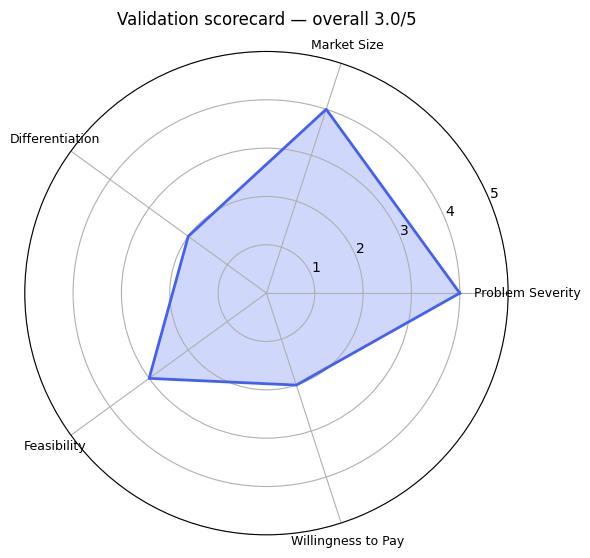

In [4]:
import numpy as np
import matplotlib.pyplot as plt

labels = list(r.scores.keys())
vals = list(r.scores.values())
angles = np.linspace(0, 2 * np.pi, len(labels), endpoint=False).tolist()
vals_c, angles_c = vals + vals[:1], angles + angles[:1]

fig, ax = plt.subplots(figsize=(6, 6), subplot_kw=dict(polar=True))
ax.plot(angles_c, vals_c, color="#4361ee", linewidth=2)
ax.fill(angles_c, vals_c, color="#4361ee", alpha=0.25)
ax.set_xticks(angles)
ax.set_xticklabels(labels, fontsize=9)
ax.set_ylim(0, 5)
ax.set_title(f"Validation scorecard — overall {r.overall}/5", pad=20)
plt.tight_layout()
plt.savefig("idea_scorecard.png", dpi=150, bbox_inches="tight")
plt.show()


## Summary

- **Validate before you build.** Five quick scores turn "cool idea" into a specific verdict.
- **The lowest scores are the plan.** Riskiest-assumption-first means you spend days, not months, learning whether the idea is dead.
- **Every risk has a cheap test.** Problem interviews, a fake-door page, a 1-day spike — none of them require building the product.

The full app adds sliders, a Lean Canvas, and an optional Claude "skeptical investor" that fills the canvas and scores the idea for you.


## Try your own idea

Replace the idea and scores, re-run, and read the riskiest-assumption experiments. Be honest on the scores — the tool is only as useful as your willingness to admit the weak spots.


In [5]:
# my_idea = "..."
# my_scores = {"Problem Severity": 3, "Market Size": 3, "Differentiation": 3, "Feasibility": 4, "Willingness to Pay": 2}
# mr = validate(my_idea, my_scores)
# print(mr.overall, mr.verdict, mr.riskiest)


---
Part of **[Phoebe's FDE Portfolio](https://github.com/phoebefu6/phoebe-the-builder)** — Day 51, Mini SaaS Products.

For the interactive Streamlit version (sliders, Lean Canvas, radar chart, optional Claude investor scoring):
```bash
pip install -r requirements.txt
streamlit run app.py
```
